# ML4Net Seminar 2
## SVM classification of human poses from Wi-Fi CSI signals

Antoine Metz 335801 | Corentin Le Bris 335776

This notebook follows the Seminar 2 subject. The goal is to use CSI Wi-Fi signals to classify human poses with an SVM.

The skeleton points are kept only to visualize what the pose looks like. The actual model is trained only with the CSI features.

## 1. Imports and paths

We import the needed libraries and define the folders used by the notebook. The path detection is kept flexible so the notebook can run with different folder organizations.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

POSSIBLE_DATA_DIRS = [
    Path("dataset_Seminar2"),
    Path("data"),
    Path("ml4net_seminar2_solution/data"),
    Path("/mnt/data/sem2_quant/ml4net_seminar2_solution/data"),
]

DATA_DIR = None
for candidate in POSSIBLE_DATA_DIRS:
    if (candidate / "Train_features.csv").exists():
        DATA_DIR = candidate
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Put the dataset folder next to this notebook, for example:\n"
        "Seminar2.ipynb\n"
        "dataset_Seminar2/Train_features.csv"
    )

OUTPUT_DIR = Path("outputs")
FIGURES_DIR = Path("figures")
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

N_SUBCARRIERS = 30
RANDOM_STATE = 42

print("Using dataset directory:", DATA_DIR.resolve())

Using dataset directory: /mnt/data/sem2_quant/ml4net_seminar2_solution/data


## 2. Dataset loading

The CSV files are loaded with `header=None` because they do not have real column names. Otherwise, the first data sample would be interpreted as a header.

In [2]:
def read_csv_matrix(path: Path) -> np.ndarray:
    return pd.read_csv(path, header=None).values


def read_labels(path: Path) -> np.ndarray:
    return read_csv_matrix(path).reshape(-1).astype(int)


def find_file(data_dir: Path, possible_names):
    for name in possible_names:
        path = data_dir / name
        if path.exists():
            return path
    raise FileNotFoundError("None of these files were found: " + str(possible_names))


def load_dataset(data_dir: Path):
    train_skeleton_path = find_file(
        data_dir,
        [
            "Train_skeletonpoints.csv",
            "Train_skelletonpoints.csv",
            "Train_SkeletonPoints.csv",
            "Train_SkelletonPoints.csv",
        ],
    )

    test_skeleton_path = find_file(
        data_dir,
        [
            "Test_skeletonpoints.csv",
            "Test_skelletonpoints.csv",
            "Test_SkeletonPoints.csv",
            "Test_SkelletonPoints.csv",
        ],
    )

    X_train = read_csv_matrix(data_dir / "Train_features.csv").astype(float)
    y_train = read_labels(data_dir / "Train_labels.csv")
    skeleton_train = read_csv_matrix(train_skeleton_path).astype(float)

    X_test = read_csv_matrix(data_dir / "Test_features.csv").astype(float)
    y_test = read_labels(data_dir / "Test_labels.csv")
    skeleton_test = read_csv_matrix(test_skeleton_path).astype(float)

    return X_train, y_train, skeleton_train, X_test, y_test, skeleton_test


X_train, y_train, skeleton_train, X_test, y_test, skeleton_test = load_dataset(DATA_DIR)

shape_summary = pd.DataFrame({
    "object": ["X_train", "y_train", "skeleton_train", "X_test", "y_test", "skeleton_test"],
    "shape": [X_train.shape, y_train.shape, skeleton_train.shape, X_test.shape, y_test.shape, skeleton_test.shape],
})

display(shape_summary)

,object,shape
0,X_train,"(1000, 270)"
1,y_train,"(1000,)"
2,skeleton_train,"(1000, 54)"
3,X_test,"(200, 270)"
4,y_test,"(200,)"
5,skeleton_test,"(400, 54)"


In [3]:
train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts = pd.Series(y_test).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class": sorted(np.unique(np.concatenate([y_train, y_test]))),
    "train_count": [train_counts.get(c, 0) for c in sorted(np.unique(np.concatenate([y_train, y_test])))],
    "test_count": [test_counts.get(c, 0) for c in sorted(np.unique(np.concatenate([y_train, y_test])))],
})
class_distribution["train_%"] = 100 * class_distribution["train_count"] / len(y_train)
class_distribution["test_%"] = 100 * class_distribution["test_count"] / len(y_test)

print("Class distribution:")
display(class_distribution.round(2))

print("Integrity checks:")
print("X_train and y_train aligned:", len(X_train) == len(y_train))
print("X_test and y_test aligned:", len(X_test) == len(y_test))
print("skeleton_train and y_train aligned:", len(skeleton_train) == len(y_train))
print("skeleton_test and y_test aligned:", len(skeleton_test) == len(y_test))

if len(skeleton_test) != len(y_test):
    print("Note: Test skeleton file has a different number of rows. This is not a problem for SVM evaluation, because the model uses only CSI features.")

Class distribution:


,class,train_count,test_count,train_%,test_%
0,1,169,42,16.9,21.0
1,2,210,39,21.0,19.5
2,3,174,35,17.4,17.5
3,4,226,38,22.6,19.0
4,5,221,46,22.1,23.0


Integrity checks:
X_train and y_train aligned: True
X_test and y_test aligned: True
skeleton_train and y_train aligned: True
skeleton_test and y_test aligned: False
Note: Test skeleton file has a different number of rows. This is not a problem for SVM evaluation, because the model uses only CSI features.


### Comment on the dataset

The dataset is correctly loaded: the training set contains 1000 samples and the test set contains 200 samples. Each CSI sample has 270 features. The labels have the same number of rows as the feature files, so each signal has its associated pose label.

The skeleton files are separate from the CSI features. They are useful for visualization, but they are not used by the SVM.

## 3. Skeleton visualization

Each row in the skeleton file represents one full pose. A row contains the coordinates of the body keypoints and, when available, a confidence value for each point.

The goal here is just to check visually what a pose label corresponds to.

Example skeleton row as a table:
Associated pose label: 1


,point_id,body_part,x,y,confidence
0,0,Nose,136.03,224.30,0.89
1,1,Neck,198.72,221.11,0.66
2,2,Right shoulder,194.99,283.05,0.64
3,3,Right elbow,241.76,349.68,0.77
4,4,Right wrist,201.30,288.04,0.74
5,5,Left shoulder,202.46,159.17,0.68
6,6,Left elbow,278.33,128.21,0.88
7,7,Left wrist,351.28,142.80,0.88
8,8,Right hip,351.28,254.65,0.69
9,9,Right knee,458.27,249.79,0.78


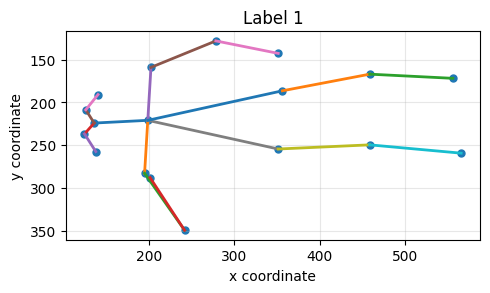

In [4]:
BODY_PARTS = {
    0: "Nose",
    1: "Neck",
    2: "Right shoulder",
    3: "Right elbow",
    4: "Right wrist",
    5: "Left shoulder",
    6: "Left elbow",
    7: "Left wrist",
    8: "Right hip",
    9: "Right knee",
    10: "Right ankle",
    11: "Left hip",
    12: "Left knee",
    13: "Left ankle",
    14: "Right eye",
    15: "Left eye",
    16: "Right ear",
    17: "Left ear",
}

SKELETON_EDGES = [
    (0, 1),
    (1, 2), (2, 3), (3, 4),
    (1, 5), (5, 6), (6, 7),
    (1, 8), (8, 9), (9, 10),
    (1, 11), (11, 12), (12, 13),
    (0, 14), (14, 16),
    (0, 15), (15, 17),
]


def split_skeleton_row(skeleton_row):
    skeleton_row = np.asarray(skeleton_row, dtype=float).reshape(-1)

    if len(skeleton_row) >= 54:
        x = skeleton_row[:18]
        y = skeleton_row[18:36]
        confidence = skeleton_row[36:54]
    elif len(skeleton_row) >= 36:
        x = skeleton_row[:18]
        y = skeleton_row[18:36]
        confidence = np.ones(18)
    else:
        raise ValueError("A skeleton row must contain at least 36 values.")

    return x, y, confidence


def skeleton_to_dataframe(skeleton_row):
    x, y, confidence = split_skeleton_row(skeleton_row)
    return pd.DataFrame({
        "point_id": range(18),
        "body_part": [BODY_PARTS[i] for i in range(18)],
        "x": x,
        "y": y,
        "confidence": confidence,
    })


def draw_pose(ax, skeleton_row, label=None, confidence_threshold=0.05):
    x, y, confidence = split_skeleton_row(skeleton_row)
    visible = confidence >= confidence_threshold

    ax.scatter(x[visible], y[visible], s=25)

    for i, j in SKELETON_EDGES:
        if confidence[i] >= confidence_threshold and confidence[j] >= confidence_threshold:
            ax.plot([x[i], x[j]], [y[i], y[j]], linewidth=2)

    ax.invert_yaxis()
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)
    if label is not None:
        ax.set_title(f"Label {label}")


def plot_pose(skeleton_row, label, confidence_threshold=0.05):
    fig, ax = plt.subplots(figsize=(5, 6))
    draw_pose(ax, skeleton_row, label, confidence_threshold)
    ax.set_xlabel("x coordinate")
    ax.set_ylabel("y coordinate")
    plt.tight_layout()
    plt.show()


sample_index = 0
print("Example skeleton row as a table:")
print("Associated pose label:", y_train[sample_index])
display(skeleton_to_dataframe(skeleton_train[sample_index]).round(2))

plot_pose(skeleton_train[sample_index], y_train[sample_index])

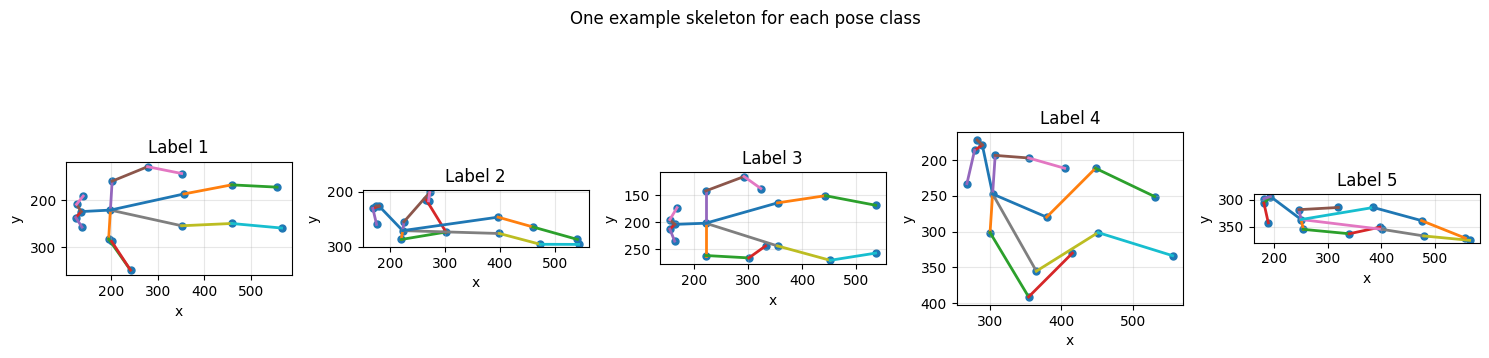

In [5]:
fig, axes = plt.subplots(1, len(np.unique(y_train)), figsize=(15, 4))

for ax, cls in zip(axes, np.unique(y_train)):
    index = np.where(y_train == cls)[0][0]
    draw_pose(ax, skeleton_train[index], label=cls)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle("One example skeleton for each pose class")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "skeleton_examples_by_class.png", dpi=300)
plt.show()

### Comment on the skeleton plots

The skeleton plots make the labels easier to understand. The numbered points correspond to body keypoints such as the nose, neck, shoulders, elbows, hips and knees.

This part is only for interpretation. The model does not learn from these points.

## 4. CSI feature analysis

Each CSI sample has 270 values. In this notebook, we interpret them as 9 groups of 30 subcarriers. For each sample, the vector is reshaped into a 9 by 30 matrix, and we average over the 9 groups to obtain one CSI amplitude profile with 30 values.

In [6]:
def csi_to_subcarrier_amplitude(X, n_subcarriers=N_SUBCARRIERS):
    X = np.asarray(X, dtype=float)
    if X.ndim == 1:
        X = X.reshape(1, -1)

    if X.shape[1] % n_subcarriers != 0:
        raise ValueError(f"Number of features {X.shape[1]} is not divisible by {n_subcarriers}.")

    n_groups = X.shape[1] // n_subcarriers
    return X.reshape(X.shape[0], n_groups, n_subcarriers).mean(axis=1)


X_train_sub = csi_to_subcarrier_amplitude(X_train)
X_test_sub = csi_to_subcarrier_amplitude(X_test)

feature_stats = pd.DataFrame({
    "set": ["train raw CSI", "test raw CSI", "train averaged CSI", "test averaged CSI"],
    "n_samples": [X_train.shape[0], X_test.shape[0], X_train_sub.shape[0], X_test_sub.shape[0]],
    "n_features": [X_train.shape[1], X_test.shape[1], X_train_sub.shape[1], X_test_sub.shape[1]],
    "mean": [X_train.mean(), X_test.mean(), X_train_sub.mean(), X_test_sub.mean()],
    "std": [X_train.std(), X_test.std(), X_train_sub.std(), X_test_sub.std()],
    "min": [X_train.min(), X_test.min(), X_train_sub.min(), X_test_sub.min()],
    "max": [X_train.max(), X_test.max(), X_train_sub.max(), X_test_sub.max()],
})

display(feature_stats.round(3))

,set,n_samples,n_features,mean,std,min,max
0,train raw CSI,1000,270,17.738,11.300,0.000,85.447
1,test raw CSI,200,270,17.688,11.399,0.000,73.449
2,train averaged CSI,1000,30,17.738,4.325,2.531,56.675
3,test averaged CSI,200,30,17.688,4.459,6.251,37.664


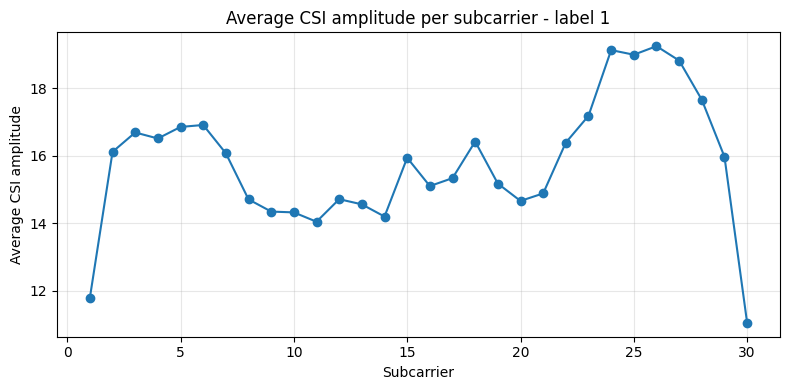

In [7]:
def plot_average_csi_per_subcarrier(sample_features, label=None, save_path=None):
    avg_amplitude = csi_to_subcarrier_amplitude(sample_features)[0]
    subcarriers = np.arange(1, len(avg_amplitude) + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(subcarriers, avg_amplitude, marker="o")
    title = "Average CSI amplitude per subcarrier"
    if label is not None:
        title += f" - label {label}"
    plt.title(title)
    plt.xlabel("Subcarrier")
    plt.ylabel("Average CSI amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()


plot_average_csi_per_subcarrier(
    X_train[sample_index],
    label=y_train[sample_index],
    save_path=FIGURES_DIR / "average_csi_sample.png",
)

### Comment on one CSI profile

The curve shows the average CSI amplitude over the 30 subcarriers for one sample. The signal is not flat, so the different subcarriers do not behave exactly the same.

This is the kind of information that the classifier can exploit later.

## 5. Distribution of CSI amplitudes by class

The boxplots show how the CSI amplitudes are distributed for each subcarrier and for each pose class. This gives a first visual idea of whether the CSI signal changes depending on the pose.

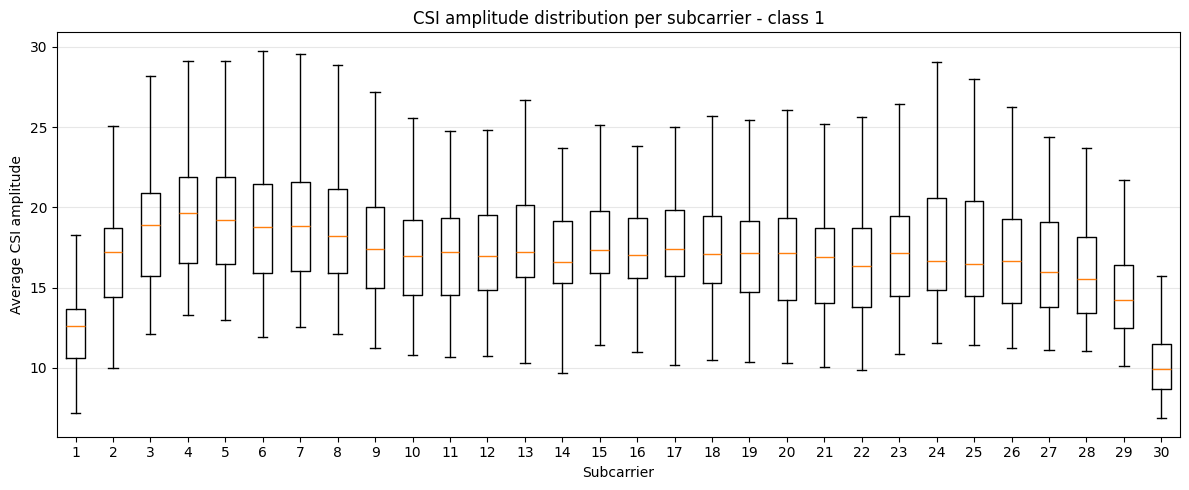

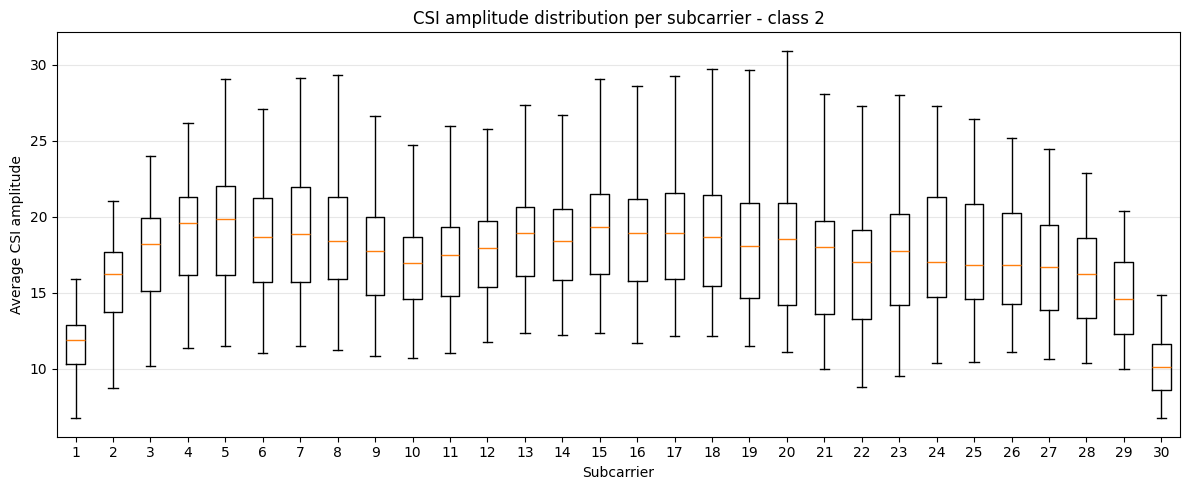

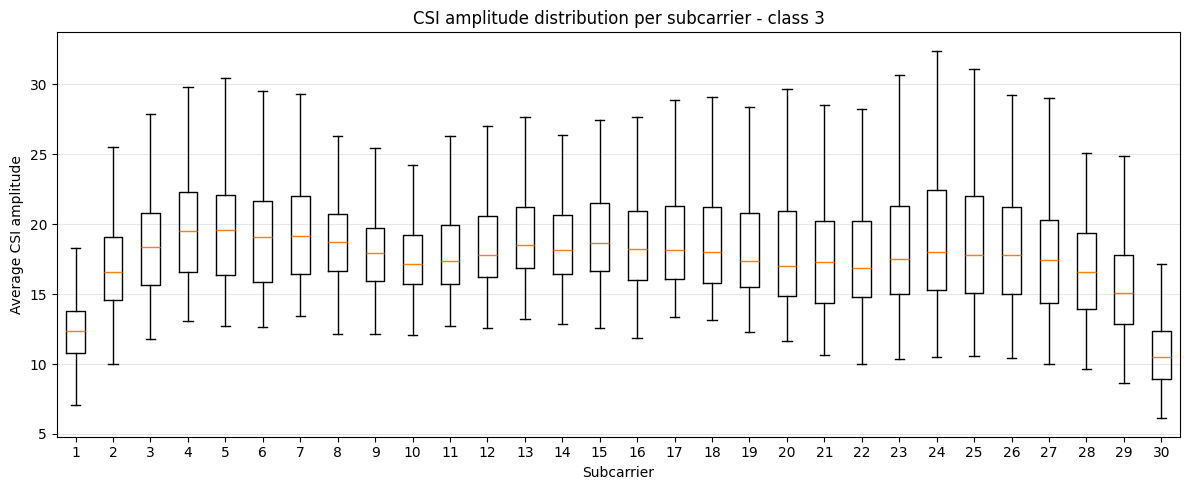

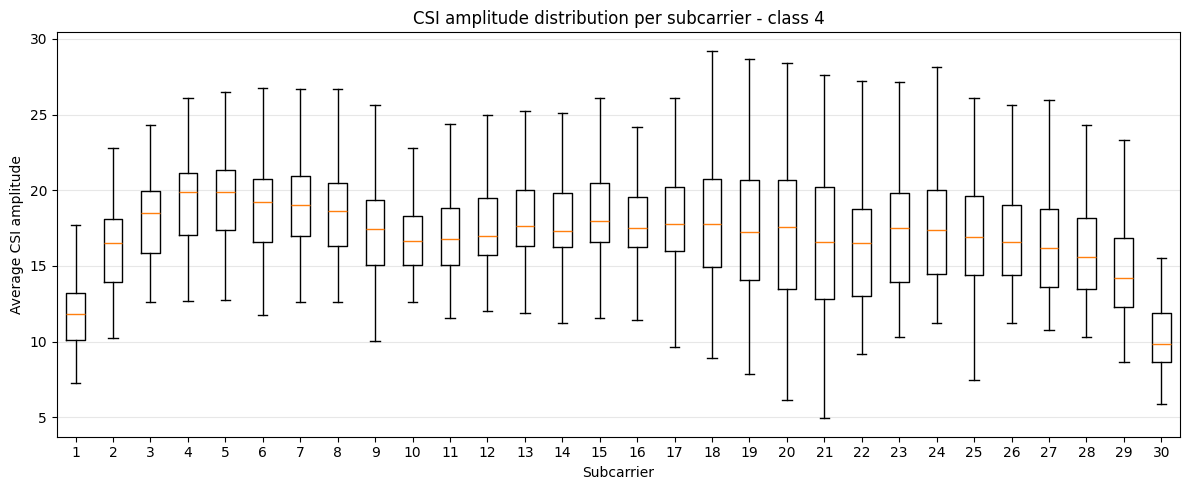

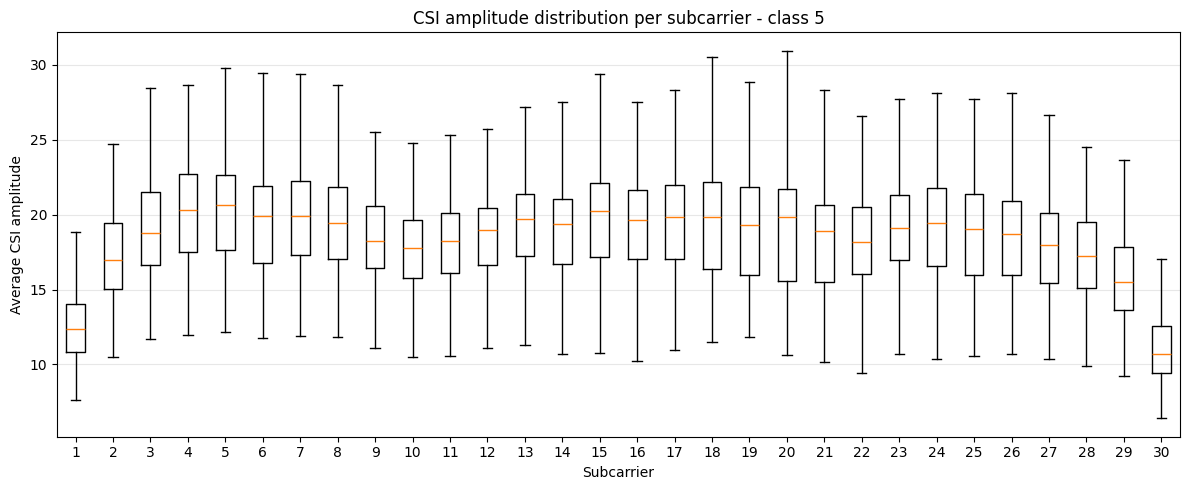

In [8]:
classes = np.unique(y_train)
subcarriers = np.arange(1, X_train_sub.shape[1] + 1)

for cls in classes:
    values = X_train_sub[y_train == cls]

    plt.figure(figsize=(12, 5))
    plt.boxplot([values[:, k] for k in range(X_train_sub.shape[1])], showfliers=False)
    plt.title(f"CSI amplitude distribution per subcarrier - class {cls}")
    plt.xlabel("Subcarrier")
    plt.ylabel("Average CSI amplitude")
    plt.xticks(subcarriers)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"csi_distribution_class_{cls}.png", dpi=300)
    plt.show()

### Comment on the class distributions

The distributions overlap quite a lot, so a single subcarrier is not enough to identify the pose. However, the shapes are not exactly the same across all classes.

This suggests that the useful information is probably spread across several subcarriers and not concentrated in only one feature.

## 6. Quantitative comparison between classes

To make the analysis less visual, we also compute a few numerical indicators. We compare the average CSI level of each class, the distance between the mean CSI profiles, and the subcarriers that vary the most between classes.

In [9]:
class_stats = []

for cls in classes:
    values = X_train_sub[y_train == cls]
    class_stats.append({
        "class": cls,
        "n_samples": len(values),
        "global_mean_amplitude": values.mean(),
        "global_std_amplitude": values.std(),
        "min_amplitude": values.min(),
        "max_amplitude": values.max(),
    })

class_stats_df = pd.DataFrame(class_stats)
display(class_stats_df.round(3))

,class,n_samples,global_mean_amplitude,global_std_amplitude,min_amplitude,max_amplitude
0,1,169,17.471,4.650,6.854,56.675
1,2,210,17.470,4.310,6.121,41.596
2,3,174,18.081,4.430,6.115,38.039
3,4,226,17.324,4.218,2.531,39.748
4,5,221,18.352,4.007,6.400,31.664


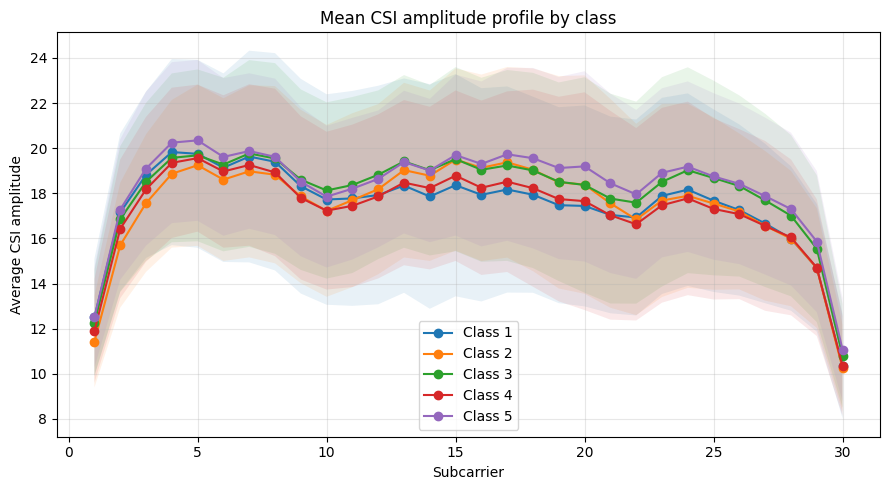

In [10]:
mean_profiles = {
    cls: X_train_sub[y_train == cls].mean(axis=0)
    for cls in classes
}

plt.figure(figsize=(9, 5))

for cls in classes:
    values = X_train_sub[y_train == cls]
    mean_values = values.mean(axis=0)
    std_values = values.std(axis=0)

    plt.plot(subcarriers, mean_values, marker="o", label=f"Class {cls}")
    plt.fill_between(subcarriers, mean_values - std_values, mean_values + std_values, alpha=0.10)

plt.title("Mean CSI amplitude profile by class")
plt.xlabel("Subcarrier")
plt.ylabel("Average CSI amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mean_csi_profile_by_class.png", dpi=300)
plt.show()

Euclidean distances between mean CSI profiles:


,1,2,3,4,5
1,0.000,4.085,4.281,1.986,5.592
2,4.085,0.000,4.017,2.590,5.311
3,4.281,4.017,0.000,4.474,2.130
4,1.986,2.590,4.474,0.000,5.870
5,5.592,5.311,2.130,5.870,0.000


Top 10 most discriminative subcarriers:


,subcarrier,between_class_variance,within_class_variance,discriminative_score
1,2,0.3393,9.7734,0.0347
0,1,0.1744,5.2442,0.0333
27,28,0.3300,11.0704,0.0298
28,29,0.2616,8.9193,0.0293
26,27,0.3522,12.8549,0.0274
2,3,0.2961,11.2850,0.0262
25,26,0.3539,13.7442,0.0257
24,25,0.3721,15.7218,0.0237
29,30,0.1067,4.8397,0.0221
23,24,0.3548,17.5022,0.0203


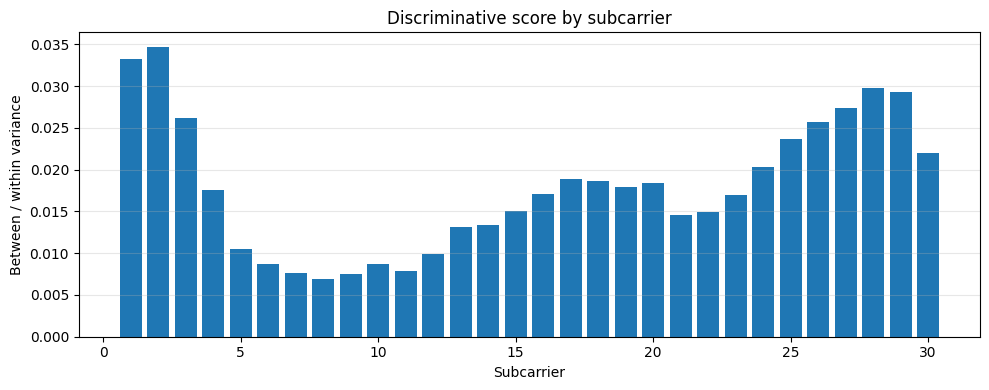

In [11]:
pairwise_distances = pd.DataFrame(index=classes, columns=classes, dtype=float)

for c1 in classes:
    for c2 in classes:
        pairwise_distances.loc[c1, c2] = np.linalg.norm(mean_profiles[c1] - mean_profiles[c2])

print("Euclidean distances between mean CSI profiles:")
display(pairwise_distances.round(3))

# Discriminative score per subcarrier.
# High value = class means differ a lot compared with within-class variability.
overall_mean = X_train_sub.mean(axis=0)
between_variance = np.zeros(X_train_sub.shape[1])
within_variance = np.zeros(X_train_sub.shape[1])

for cls in classes:
    values = X_train_sub[y_train == cls]
    class_mean = values.mean(axis=0)
    between_variance += len(values) * (class_mean - overall_mean) ** 2
    within_variance += ((values - class_mean) ** 2).sum(axis=0)

between_variance /= len(X_train_sub)
within_variance /= len(X_train_sub)
score = between_variance / (within_variance + 1e-12)

discriminative_df = pd.DataFrame({
    "subcarrier": subcarriers,
    "between_class_variance": between_variance,
    "within_class_variance": within_variance,
    "discriminative_score": score,
}).sort_values("discriminative_score", ascending=False)

print("Top 10 most discriminative subcarriers:")
display(discriminative_df.head(10).round(4))

plt.figure(figsize=(10, 4))
plt.bar(discriminative_df["subcarrier"], discriminative_df["discriminative_score"])
plt.title("Discriminative score by subcarrier")
plt.xlabel("Subcarrier")
plt.ylabel("Between / within variance")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "discriminative_score_by_subcarrier.png", dpi=300)
plt.show()

### Comment on the quantitative CSI analysis

The global CSI means are quite close from one class to another. This means that the model cannot simply classify a pose by looking at the overall average amplitude.

The pairwise distances between class profiles and the discriminative subcarrier scores are more informative. They show that differences exist, but they are distributed across the CSI profile. This explains why using the full 270-feature vector is more useful than relying only on a simple average.

## 7. SVM model training

The SVM takes the 270 CSI features as input and predicts the pose label. We use a `StandardScaler` before the SVM because SVM models are sensitive to the scale of the input features.

In [12]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale")),
])

svm_rbf.fit(X_train, y_train)
y_pred = svm_rbf.predict(X_test)

print("SVM training completed.")
print("First 20 true labels:     ", y_test[:20])
print("First 20 predicted labels:", y_pred[:20])

SVM training completed.
First 20 true labels:      [1 1 5 1 4 5 3 2 1 1 5 1 1 2 1 5 2 1 4 1]
First 20 predicted labels: [5 1 5 1 4 5 5 2 1 1 5 1 1 2 1 5 2 1 4 1]


### Quick comment on the predictions

The first predictions already show the general behavior of the model: most labels are correctly predicted, but there are still some mistakes. This is expected because some poses can produce similar CSI patterns.

## 8. Evaluation metrics

We evaluate the model with accuracy, balanced accuracy, macro F1-score and weighted F1-score. These metrics give both a global view of performance and a more class-balanced view.

In [13]:
metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
    "macro_precision": precision_score(y_test, y_pred, average="macro"),
    "macro_recall": recall_score(y_test, y_pred, average="macro"),
    "macro_f1": f1_score(y_test, y_pred, average="macro"),
    "weighted_f1": f1_score(y_test, y_pred, average="weighted"),
}

metrics_df = pd.DataFrame([metrics]).T.reset_index()
metrics_df.columns = ["metric", "value"]

display(metrics_df.round(4))

n_correct = int((y_test == y_pred).sum())
n_total = len(y_test)
n_errors = n_total - n_correct
print(f"Correct predictions: {n_correct}/{n_total}")
print(f"Errors: {n_errors}/{n_total}")
print(f"Accuracy: {100 * n_correct / n_total:.2f}%")
print(f"Error rate: {100 * n_errors / n_total:.2f}%")

,metric,value
0,accuracy,0.8650
1,balanced_accuracy,0.8660
2,macro_precision,0.8682
3,macro_recall,0.8660
4,macro_f1,0.8666
5,weighted_f1,0.8652


Correct predictions: 173/200
Errors: 27/200
Accuracy: 86.50%
Error rate: 13.50%


### Comment on the global performance

The RBF SVM reaches 86.5% accuracy on the test set. In practice, this corresponds to 173 correct predictions out of 200 samples, with 27 errors.

The balanced accuracy and the F1-scores are close to the accuracy, which means that the result is not only due to one class being easier or more frequent. Overall, this is a solid baseline for a simple SVM trained on Wi-Fi CSI features.

In [14]:
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).T

display(report_df.round(3))

report_text = classification_report(y_test, y_pred)
print(report_text)

,precision,recall,f1-score,support
1,0.878,0.857,0.867,42.000
2,0.833,0.897,0.864,39.000
3,0.886,0.886,0.886,35.000
4,0.914,0.842,0.877,38.000
5,0.830,0.848,0.839,46.000
accuracy,0.865,0.865,0.865,0.865
macro avg,0.868,0.866,0.867,200.000
weighted avg,0.866,0.865,0.865,200.000


              precision    recall  f1-score   support

           1       0.88      0.86      0.87        42
           2       0.83      0.90      0.86        39
           3       0.89      0.89      0.89        35
           4       0.91      0.84      0.88        38
           5       0.83      0.85      0.84        46

    accuracy                           0.86       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.86      0.87       200



### Comment on the class-by-class results

The classification report shows that all classes are recognized reasonably well. Some classes have slightly better F1-scores than others, which means that certain poses are easier to distinguish from the CSI signal.

The weakest class is still not completely missed, so the model has learned useful patterns for every pose label.

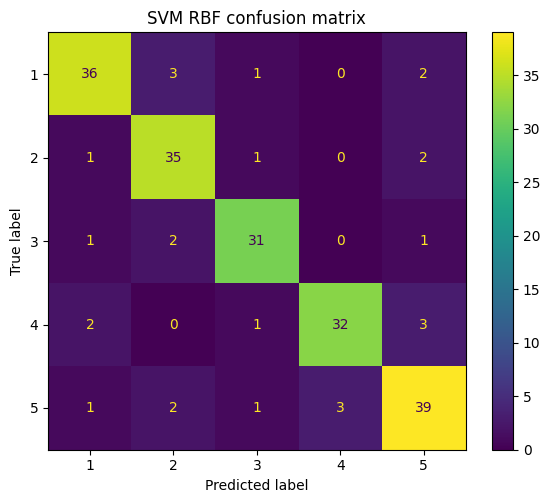

Errors by true class:


,true_label,n_errors,test_count,error_rate_%
0,1,6,42,14.29
1,2,4,39,10.26
2,3,4,35,11.43
3,4,6,38,15.79
4,5,7,46,15.22


In [15]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(values_format="d", ax=ax)
plt.title("SVM RBF confusion matrix")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "confusion_matrix_svm_rbf.png", dpi=300)
plt.show()

errors_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred,
    "correct": y_test == y_pred,
})

errors_by_class = (
    errors_df[errors_df["correct"] == False]
    .groupby("true_label")
    .size()
    .reindex(classes, fill_value=0)
    .reset_index(name="n_errors")
)
errors_by_class["test_count"] = [test_counts.get(c, 0) for c in classes]
errors_by_class["error_rate_%"] = 100 * errors_by_class["n_errors"] / errors_by_class["test_count"]

print("Errors by true class:")
display(errors_by_class.round(2))

### Comment on the confusion matrix

The confusion matrix gives a clearer view of the mistakes. The errors are spread across different classes instead of being concentrated on only one label.

This suggests that the model is not completely biased toward one class. The remaining mistakes are more likely due to overlap between CSI patterns for similar poses or to noise in the Wi-Fi measurements.

## 9. Comparison with simple baselines

To check that the SVM result is meaningful, we compare it with a dummy classifier and with a linear SVM. This helps us see whether the RBF SVM really brings an improvement.

,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Dummy most frequent,0.190,0.2000,0.0639,0.0607
1,Linear SVM,0.645,0.6479,0.6433,0.6428
2,RBF SVM,0.865,0.8660,0.8666,0.8652


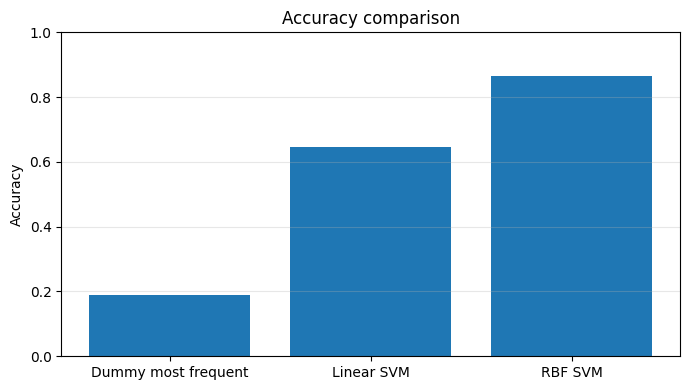

In [16]:
models = {
    "Dummy most frequent": DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", LinearSVC(C=1.0, max_iter=20000, random_state=RANDOM_STATE)),
    ]),
    "RBF SVM": svm_rbf,
}

comparison_rows = []

for name, model in models.items():
    if name != "RBF SVM":
        model.fit(X_train, y_train)
    pred = model.predict(X_test)
    comparison_rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "weighted_f1": f1_score(y_test, pred, average="weighted"),
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df.round(4))

plt.figure(figsize=(7, 4))
plt.bar(comparison_df["model"], comparison_df["accuracy"])
plt.ylim(0, 1)
plt.title("Accuracy comparison")
plt.ylabel("Accuracy")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_accuracy_comparison.png", dpi=300)
plt.show()

### Comment on the baseline comparison

The dummy classifier performs poorly, which confirms that the final result is not just due to class imbalance. The linear SVM is better, but it remains clearly below the RBF SVM.

This comparison is useful because it shows that the CSI data contain real information about the pose, and that a non-linear classifier is better suited for this dataset.

## 10. Saving outputs

At the end, we save the predictions, metrics, classification report and model comparison tables so the results can be reused later.

In [17]:
predictions_df = pd.DataFrame({
    "true_label": y_test,
    "predicted_label": y_pred,
    "correct": y_test == y_pred,
})

predictions_df.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
metrics_df.to_csv(OUTPUT_DIR / "metrics.csv", index=False)
report_df.to_csv(OUTPUT_DIR / "classification_report.csv")
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

with open(OUTPUT_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump({key: float(value) for key, value in metrics.items()}, f, indent=4)

print("Saved outputs in:", OUTPUT_DIR.resolve())
print("Saved figures in:", FIGURES_DIR.resolve())

Saved outputs in: /outputs
Saved figures in: /figures


## Final summary and conclusion

In this seminar, we built a complete pipeline for human pose classification using Wi-Fi CSI signals.

First, we loaded the train and test CSV files and checked that the features, labels and skeleton data were correctly aligned. Then, we visualized some skeleton poses to understand what the labels represent. These skeleton points were only used for visualization.

After that, we analyzed the CSI features. We reshaped the CSI vectors into groups of subcarriers, plotted average CSI profiles, compared the distributions by class, and added a few quantitative indicators to see how the classes differ.

Finally, we trained an SVM classifier on the CSI features and evaluated it on the test set. The RBF SVM obtained about 86.5% accuracy, which means that the model can classify most poses correctly using only Wi-Fi signals.

The main conclusion is that the CSI signal contains enough information to recognize human poses without directly using camera images. The skeleton data help us understand the labels visually, but the classification itself is done from Wi-Fi CSI features only.